# T1 - Introdução à Ciência de Dados
**Alunas:** Aline Manhães e Maria Luiza Ferreira

**Colab:** [Link](https://colab.research.google.com/drive/1ox4yTTRR1HHoqHVvupxf-8MHXe1TWe2L?usp=sharing)

O objetivo geral deste trabalho é praticar os conceitos discutidos em sala de aula, principalmente: representação e pré-processamento de dados textuais; redução de dimensionalidade e algoritmos de agrupamento.

Tais estudos serão aplicados num conjunto de dados de jogos da Steam, que foi obtido de datasets públicos da Steam disponibilizados no Kaggle.

O objetivo final do trabalho é investigar se há relação entre a descrição de um jogo e o(s) gênero(s) ao(s) qual(quais) ele pertence.

Escolhemos utilizar a descrição detalhada (`description`), porque a descrição resumida (`short_description`) possui frases curtas demais e com sentidos que não refletem completamente como o seu respectivo jogo realmente é, ao comparar com a descrição detalhada.

Esse trabalho e seus códigos foram rodados em computadores com as seguintes configurações:

Computador 1: Inspirion 15 3520 (16GB de RAM, Core i5 11th geração)

Computador 2: macbook air M4 de 16GB de RAM


## Importando bibliotecas

Primeiro, vamos instalar e importar todas as bibliotecas que serão necessárias para a execução de todo o trabalho.

In [ ]:
!pip install unidecode

In [ ]:
import pandas as pd
import seaborn as sns
import string
import unidecode
import nltk
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.cluster
import scipy.cluster.hierarchy as hierarchy
import itertools

from sklearn.cluster import KMeans
nltk.download('punkt_tab')
from nltk import word_tokenize
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn import cluster, datasets
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.datasets import load_iris
from collections import Counter
from sklearn.metrics import silhouette_score

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Abrindo a base de dados

Agora vamos abrir a base de dados que será utilizada para todo o trabalho. Além disso, selecionaremos uma amostra aleatória dessa base de dados, a fim de executar as operações do trabalho de forma mais rápida e eficiente. Para amostras de 10k jogos ou mais, os computadores demoravam muito ou os processos se matavam. Por isso, escolhemos ter 8k jogos na amostra.

In [ ]:
#abrindo arquivo e pegando uma amostra aleatória
steamFile = pd.read_csv("steam_games.csv")
steamFileSample = steamFile.sample(8000)

## Pré-processamento dos dados textuais

Abaixo, foi realizado o pré-processamento dos dados textuais de descrição das amostras aleatórias selecionadas no passo anterior. Foram retiradas tags e marcações html, através de BeautifulSoup, e também foram retiradas pontuações, stopwords e palavras não alfabéticas, além da realização de stemming e transformação das palavras para minúsculo.

In [ ]:
def soup(steamFile):
    steamFile['description'] = [BeautifulSoup(d, 'html.parser').get_text() for d in steamFile['description']]

def preProcessing(steamFile):
    soup(steamFile)
    dirtyDescriptions = steamFile['description']
    dirtyDescriptionsTokens = [word_tokenize(i) for i in dirtyDescriptions]

    table = str.maketrans('', '', string.punctuation)
    dirtyDescriptionsTokens = [
          [unidecode.unidecode(word).translate(table).lower() for word in row ]
          for row in dirtyDescriptionsTokens
        ]

    stop_words = set(stopwords.words('english'))
    porter = PorterStemmer()
    dirtyDescriptionsWords = [[porter.stem(word) for word in row if word.isalpha() and not word in stop_words] for row in dirtyDescriptionsTokens]
    sentences = [" ".join(row) for row in dirtyDescriptionsWords]
    return sentences

#pré-processamento, com remoção de html, stopwords, pontuação e stemming
descriptions = preProcessing(steamFileSample)

## Construção da matriz de TF-IDF

Aqui, foi construída a matriz TF-IDF, a partir dos dados pré-processados no passo anterior. Como parâmetros da função, foram escolhidos:
- min_df = 8, para eliminar palavras que apareçam em poucos dados (nesse caso, menos que 8 jogos) e que devem ser irrelevantes para o futuro agrupamento. Escolhemos esse valor porque é dos menores mínimos que os nossos computadores conseguem rodar sem os processos se matarem e acreditamos que seja um valor suficiente para eliminar dados irrelevantes;
- ngram_range = (1, 3), para analisar a presença das palavras nas frases com um contexto maior, pegando até 3 palavras em sequência;
- max_df = 0.95, para eliminar palavras que apareçam em mais do que 95% dos casos, a fim de evitar palavras genéricas e que não nos forneçam informações úteis para o agrupamento.

In [ ]:
def tfidf(descriptions):
    vectorizer = TfidfVectorizer(min_df = 8, ngram_range = (1, 3), max_df = 0.95)
    X = vectorizer.fit_transform(descriptions)
    df = pd.DataFrame(X.todense(), columns = vectorizer.get_feature_names_out())
    return df

#realiza o tfidf
tfidfMatrix = tfidf(descriptions)

## Redução de dimensionalidade via PCA

Para conseguirmos visualizar a distribuição dos gêneros com base na descrição, precisamos aplicar o PCA no nosso conjunto de dados para combater a maldição da dimensionalidade. Com o objetivo de descobrirmos para quantas dimensões a nossa matriz será reduzida, utilizamos, primeiramente, a função abaixo. Ela gera um gráfico que correlaciona o número de componentes com a variância explicada acumulada. A função também retorna o valor exato de componentes que tornam a variância de 0.8, o que mantém a boa qualidade dos dados originais e impacta no resultado final, e por isso, será o valor que utilizaremos como número de componentes no PCA, no próximo passo.

3855


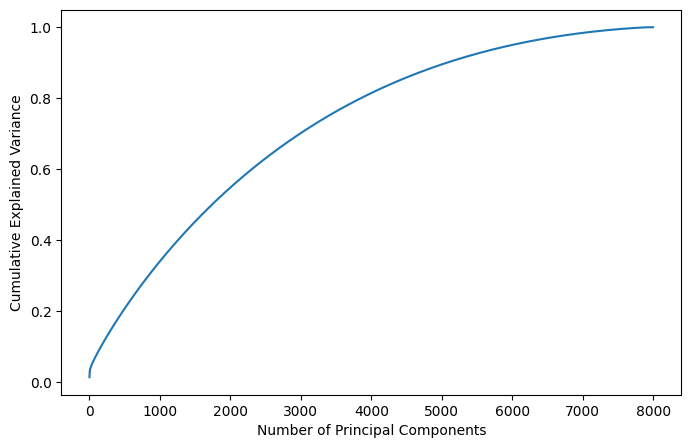

In [ ]:
def numComponentsPCA(X):
    tfidfMatrix = X.copy()
    pca = PCA()
    scaler = StandardScaler(with_mean=True, with_std=True)
    tfidfMatrix[tfidfMatrix.columns] = scaler.fit_transform(tfidfMatrix)
    X2  = pca.fit(tfidfMatrix)

    #numero de componentes ideais para 80% de variância
    threshold = 0.80
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    nComponents = np.argmax(cumulative_variance >= threshold) + 1
    print(nComponents)
   #grafico plotado para a variância dado o número de componentes
    plt.figure(figsize=(8, 5))
    plt.plot(np.cumsum(pca.explained_variance_ratio_))
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.show()
    return nComponents

#calcula o número ideal de componentes para o pca
nComponentsPCA = numComponentsPCA(tfidfMatrix)

Para a última vez que a função acima foi executada, o valor retornado foi 3855 e o gráfico gerado foi:
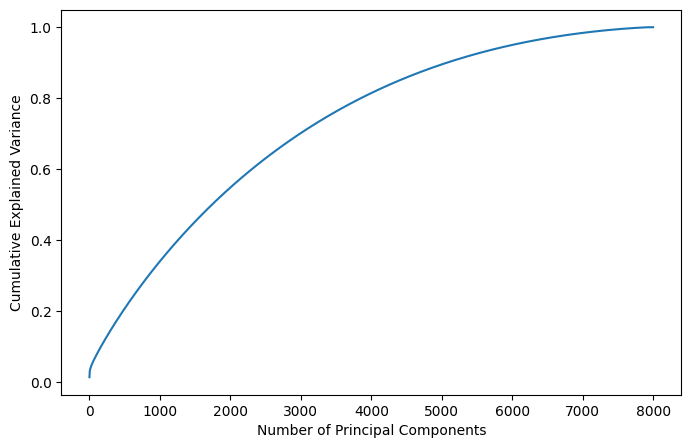

Agora, aplicamos no PCA o número de componentes que atinge a variância 0.8. Esse passo pode ser visualizado na função abaixo, que retorna a matriz reduzida gerada via PCA. Essa matriz será utilizada a partir de agora para os próximos passos.

In [ ]:
def pca(X, numComponents):
    tfidfMatrix = X.copy()
    pca = PCA(n_components = numComponents)
    scaler = StandardScaler(with_mean=True, with_std=True)
    tfidfMatrix[tfidfMatrix.columns] = scaler.fit_transform(tfidfMatrix)
    X2  = pca.fit_transform(tfidfMatrix)
    return X2

#realiza o pca, com um número ideal de componentes calculado
pcaMatrix = pca(tfidfMatrix, nComponentsPCA)

Visualização da matriz retornada pela função de PCA:

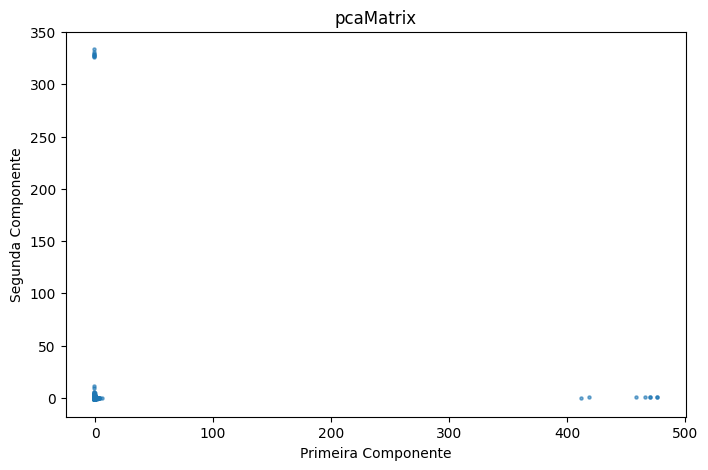

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(pcaMatrix[:, 0], pcaMatrix[:, 1], s=5, alpha=0.6)
plt.xlabel('Primeira Componente')
plt.ylabel('Segunda Componente')
plt.title(r'pcaMatrix')
plt.show()

## Aplicação de algoritmos de agrupamento

A seguir, a matriz PCA será aplicada em dois algoritmos de agrupamentos diferentes: K-Means e Agrupamento Hierárquico.

### K-Means

A fim de selecionarmos um valor ideal para o k, executamos, inicialmente, a função abaixo, que executa o algoritmo k-means para 45 valores de k (quantidade de grupos) diferentes. A partir disso, é gerado um gráfico que correlaciona os diferentes valores de k testados com a sua inércia calculada. Idealmente, a partir desse gráfico, deveríamos poder concluir qual valor de k representa o cotovelo na função e, portanto, o valor ideal de k para a aplicação do k-means.

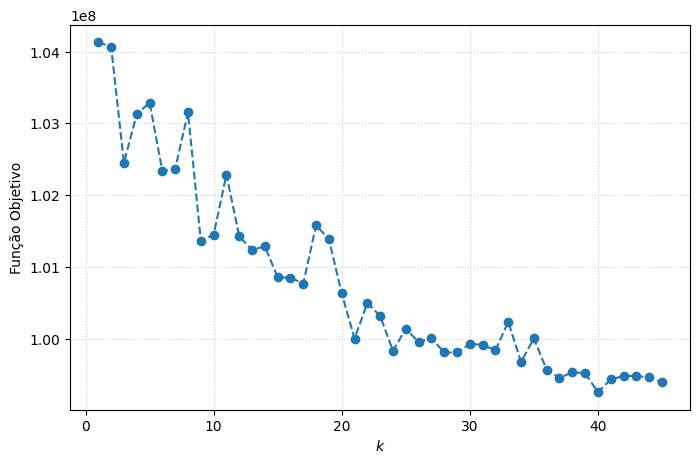

In [ ]:
def findingK(matrix):
    inertia = []
    for i in range(1, 46):
        km = KMeans(n_clusters = i, random_state=42, n_init=10)
        km.fit(matrix)
        inertia.append(km.inertia_)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 46), inertia, marker='o', linestyle='--')
    _ = plt.ylabel("Função Objetivo")
    _ = plt.xlabel(r"$k$")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

#procura um k ideal para o k-means
findingK(pcaMatrix)

É possível perceber que a função acima não foi muito efetiva em seu objetivo, visto que não há um cotovelo ideal porque a função varia muito, subindo e descendo. Ainda assim, o grupo considerou que os valores de k mais próximos do ideal foram 9, 15 e 24.

O primeiro (k=9) foi selecionado porque vem de uma queda muito grande pelo se valor anterior e uma variação muito pequena para o seu valor posterior. k=15 foi selecionado pelos mesmos motivos do k=9, ainda que a queda anterior ao 9 fosse maior que a do 15. Por fim, a partir do k=24 as variações entre os valores de k diminuem bastante, por isso este foi selecionado. Rodaremos o algoritmo com os 3 valores para comparar seus resultados, uma vez que nenhum deles demonstrou ser, precisamente, o valor ideal para o k.

Colocamos, a seguir, uma foto do gráfico que gerou essa conclusão, pois, como as amostras são aleatórias, o gráfico pode variar.
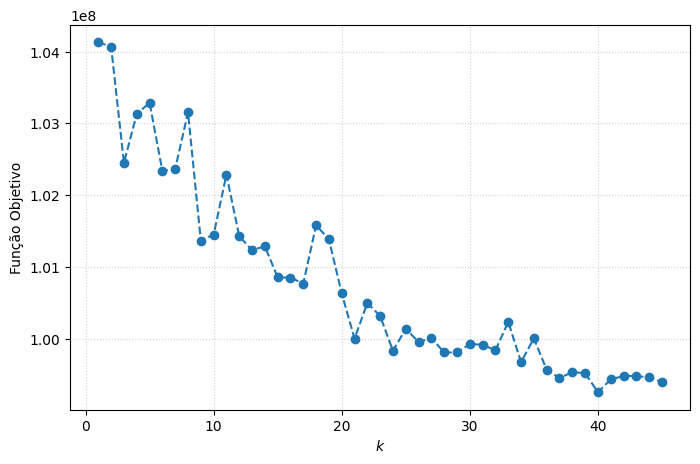

Como não consideramos o resultado acima como ideal e certeiro, resolvemos tentar uma outra maneira de identificar o melhor k: através do método da silhueta. Esse método foi implementado na função abaixo, que realiza cálculos de "silhouette_score" para valores de k de 2 a 45 e projeta em um gráfico a correlação entre os dois valores citados. Para fins de avaliação, quanto mais próximo de 1 (em "silhouette_score"), melhor o k, e quanto mais próximo de -1 (em "silhouette_score"), pior o k.

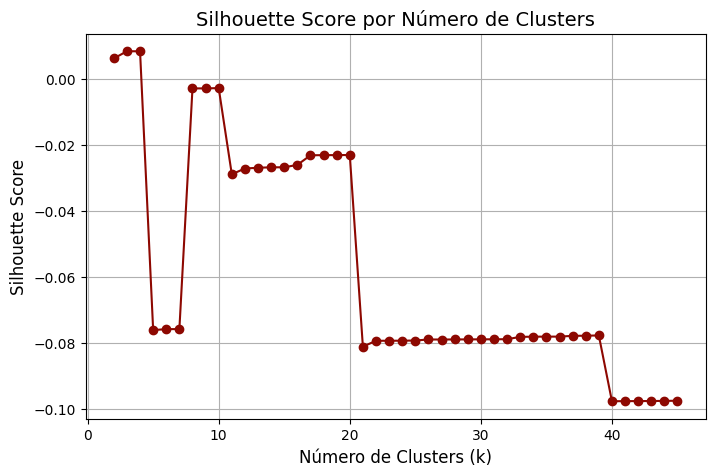

In [ ]:
def silhueta(X):
  silhouette_scores = []
  for k in range(2, 46):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(score)

  plt.figure(figsize=(8, 5))
  plt.plot(range(2, 46), silhouette_scores, '-o', color='#8d0801')
  plt.title('Silhouette Score por Número de Clusters', fontsize=14)
  plt.xlabel('Número de Clusters (k)', fontsize=12)
  plt.ylabel('Silhouette Score', fontsize=12)
  plt.grid()
  plt.show()

silhueta(pcaMatrix)

A conclusão a partir do método acima é que todos os valores de k testados estão muito próximos do valor médio 0 de "silhouette_score", variando somente no pequeno intervalo [-0.1, 0.1). A nossa opinião é que os resultados visualizados são inconclusivos, devido a essa pequena variação dos valores de "silhouette_score". Ainda que o melhor k tenha sido k=4, seu valor foi bem próximo de 0, que não é um bom resultado. Da mesma forma que foi feito no método anterior, colocamos, a seguir, uma foto do gráfico que gerou essa conclusão, pois, como as amostras são aleatórias, o gráfico pode variar.

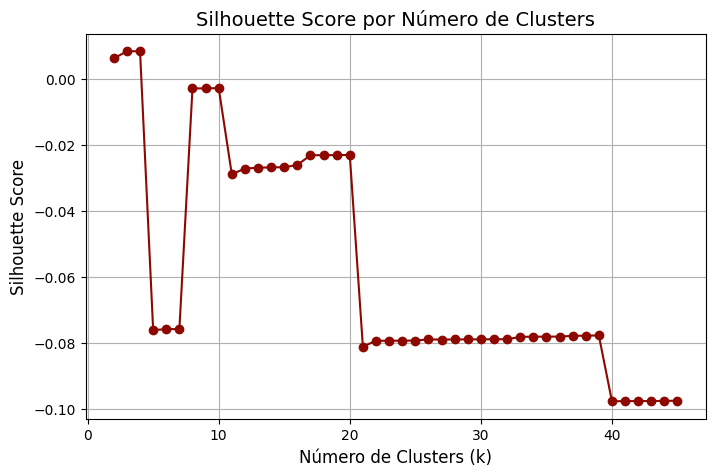

Por fim, ainda que os resultados tenham se mostrado inconclusivos, seguiremos apenas com os valores de k levantados pela análise do gráfico da função "findingK", ou seja, resolvemos realizar o k-means com os valores k= 9, 15 e 24, que foram razoavelmente melhores avaliados no primeiro método.

In [ ]:
def kMeans(clusterNumber, matrix):
    kmeans = KMeans(n_clusters = clusterNumber, random_state=42, n_init=10)
    kmeans.fit(matrix)
    y_kmeans = kmeans.predict(matrix)

    plt.figure(figsize=(8, 5))
    plt.scatter(matrix[:, 0], matrix[:, 1], c=y_kmeans, s=5, cmap='viridis', alpha=0.6)
    centers = kmeans.cluster_centers_
    plt.scatter(centers[:, 0], centers[:, 1], c='red', s=150, marker='X', label='Centroides')
    plt.xlabel('Primeira Componente')
    plt.ylabel('Segunda Componente')
    plt.legend(loc = 'best')
    k = clusterNumber
    plt.title(r'Resultados $k$-means')
    plt.show()

    return y_kmeans

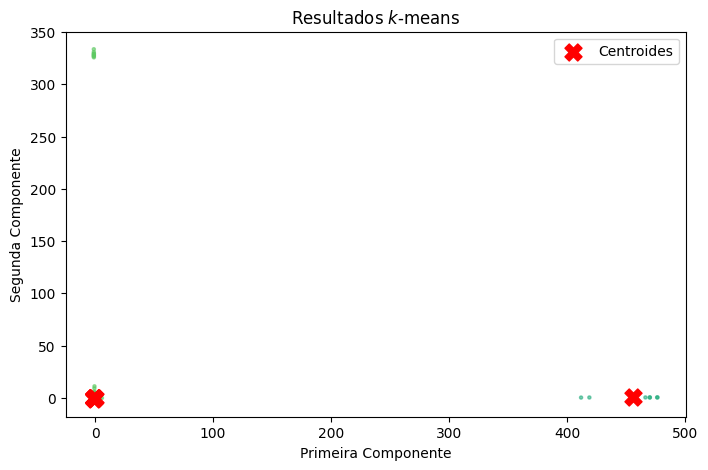

In [ ]:
matrixKMeans9 = kMeans(9, pcaMatrix)

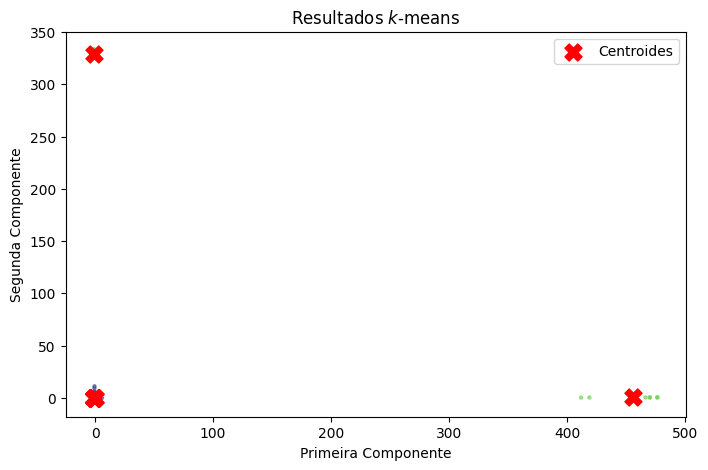

In [ ]:
matrixKMeans15 = kMeans(15, pcaMatrix)

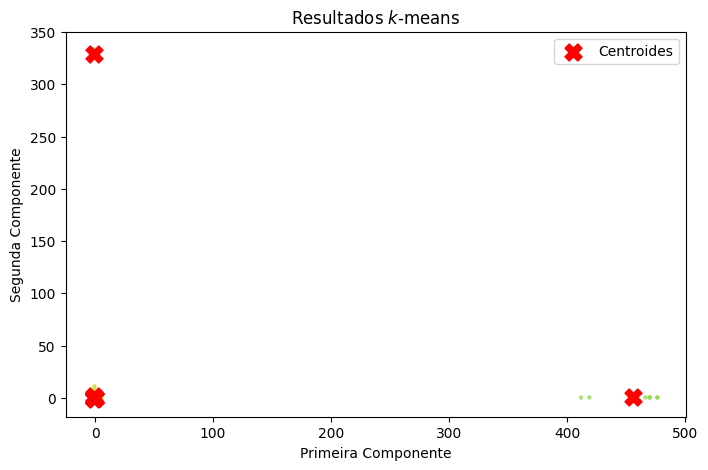

In [ ]:
matrixKMeans24 = kMeans(24, pcaMatrix)

Devido à disposição das muitas componentes da matriz do PCA, o gráfico gerado aqui no k-means para os 3 valores de k não fica muito visual. É difícil transmitir milhares de componentes em apenas duas em um gráfico. Mais a frente, analisaremos melhor esses resultados.

### Agrupamento Hierárquico

O segundo algoritmo de agrupamento que utilizaremos é o agrupamento hierárquico. Escolhemos a distância de Ward como método, pois acreditamos que o questionamento feito por essa distância "se combinarmos esses dois grupos, quanto o agrupamento melhoraria?" é útil e pode gerar resultados interessantes.

Na função abaixo, com base na matriz reduzida no PCA, calculamos a distância entre os clusters (função linkage), geramos um dendograma desses dados e um gráfico que associa dados do recolhimento das distâncias das últimas 50 junções com o número de clusters. Esse último gráfico tem como objetivo implementar o método do cotovelo e tornar possível a identificação de um número de clusters ideal.

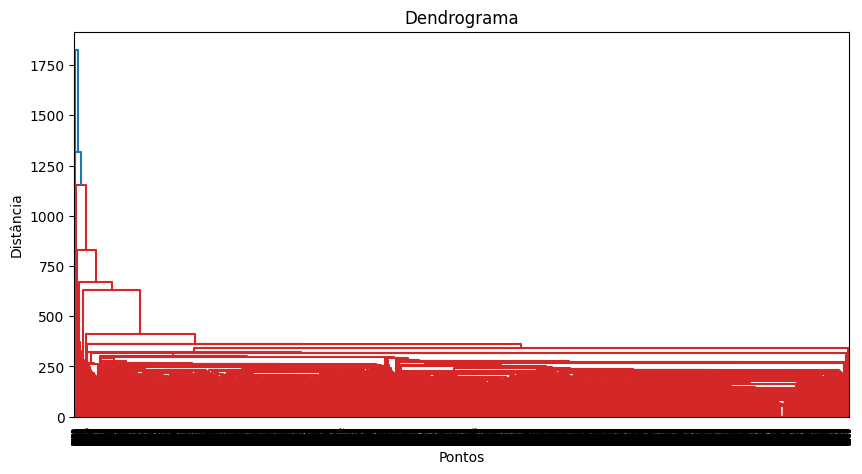

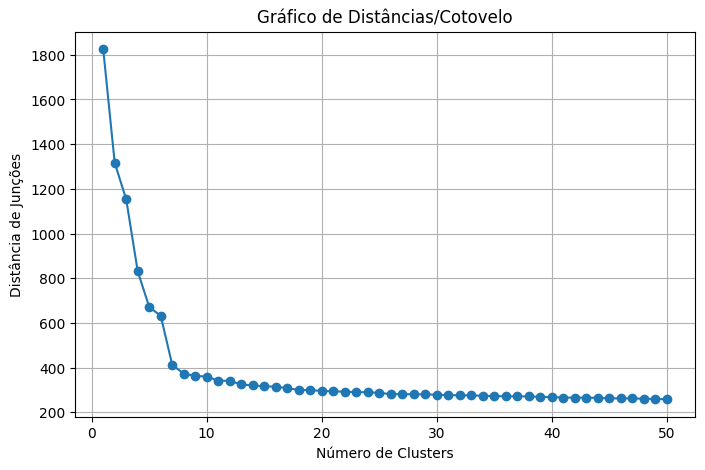

In [ ]:
def dendrogramImage(matrix):
  hierarchyMatrix = linkage(matrix, method='ward')

  #Dendrograma
  plt.figure(figsize=(10, 5))
  dendrogram(hierarchyMatrix)
  plt.title("Dendrograma")
  plt.xlabel("Pontos")
  plt.ylabel("Distância")
  plt.show()

  #Gráfico de Distâncias/Cotovelo
  last = hierarchyMatrix[-50:, 2] #pega as distâncias entre junções
  last_rev = last[::-1] #inverte a matriz para pegar o número de clusters em ordem crescente

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, 51), last_rev, marker='o')
  plt.title('Gráfico de Distâncias/Cotovelo')
  plt.xlabel('Número de Clusters')
  plt.ylabel('Distância de Junções')
  plt.grid(True)
  plt.show()

dendrogramImage(pcaMatrix)

O dendrograma gerado, devido ao número de dados analisado, ficou confuso e poluído, portanto, é difícil concluir algo:
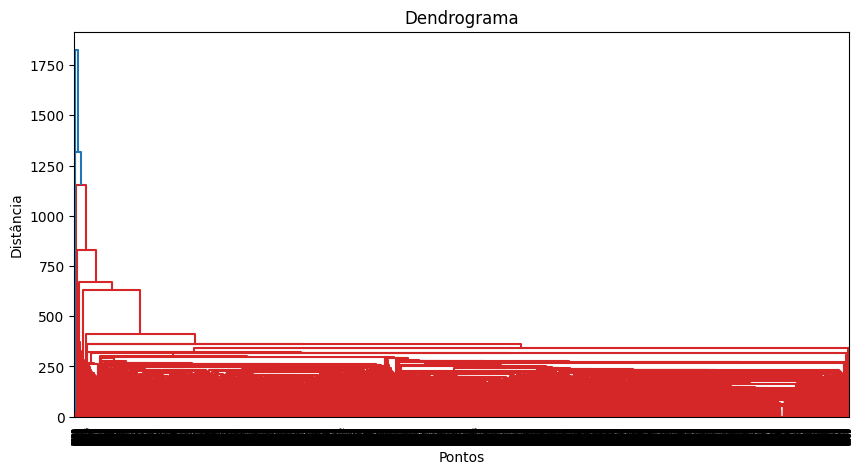

O gráfico de distâncias/cotovelo, porém, se mostrou útil, pois demonstrou com mais clareza as distâncias entre diferentes números de clusters. Em sua análise, concluímos que o número de clusters ideal é 7, pois representa o "cotovelo" do gráfico.

O gráfico que gerou essa conclusão pode ser visualizado a seguir:
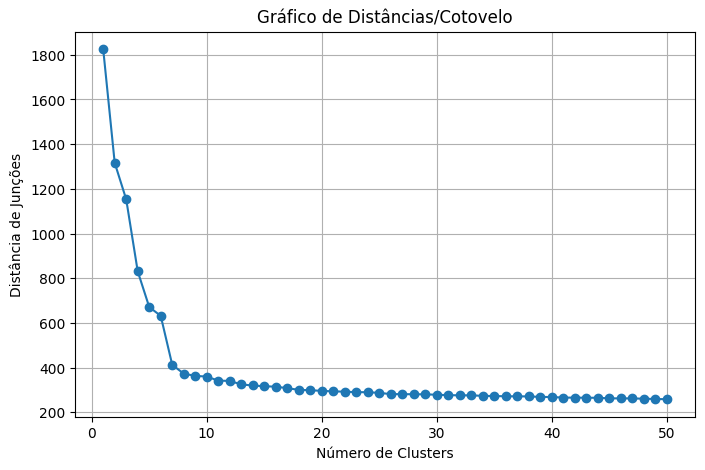

Aplicamos, portanto, o algoritmo de agrupamento hierárquico com distância de Ward para 7 clusters diferentes a seguir. Rodaremos também com outros números de clusters distintos para fins de análise no final. Escolhemos 5, 10 e 24 clusters. O primeiro (5) pois possui uma queda grande antes dele e uma queda bem mais leve após. O segundo (10) pois, após regularizar a queda, este é o primeiro valor a ter uma queda levemente mais intensa. O terceiro (24) pois foi selecionado para o k-means e é um valor que varia bastante dos anteriormente selecionados aqui. A função abaixo também exibe o gráfico da matriz gerada no PCA com o resultado produzido pelo agrupamento hierárquico.

In [ ]:
def doAgglomerativeClustering(clusterAmount, matrix):
    aGWard = AgglomerativeClustering(n_clusters= clusterAmount, linkage = 'ward')
    clust = aGWard.fit_predict(matrix)

    plt.figure(figsize=(8, 5))
    plt.scatter(matrix[:, 0], matrix[:, 1], c=aGWard.labels_, s=5, cmap='viridis', alpha=0.6)
    plt.xlabel('Primeira Componente')
    plt.ylabel('Segunda Componente')
    plt.title(r'Resultados Agrupamento Hierárquico')
    plt.show()

    return clust

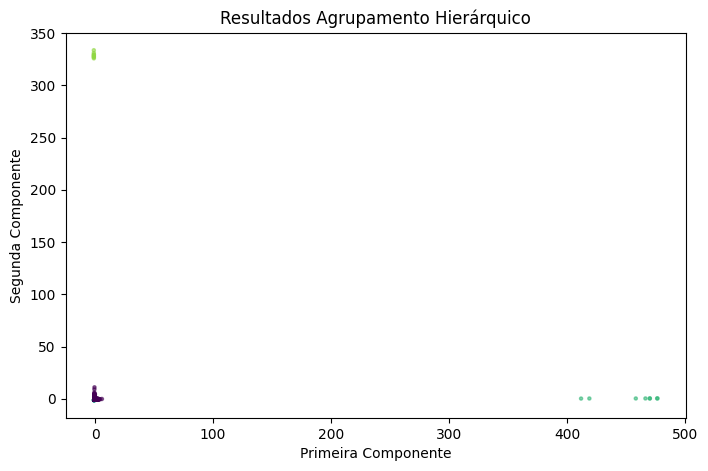

In [ ]:
matrixAH7 = doAgglomerativeClustering(7, pcaMatrix)

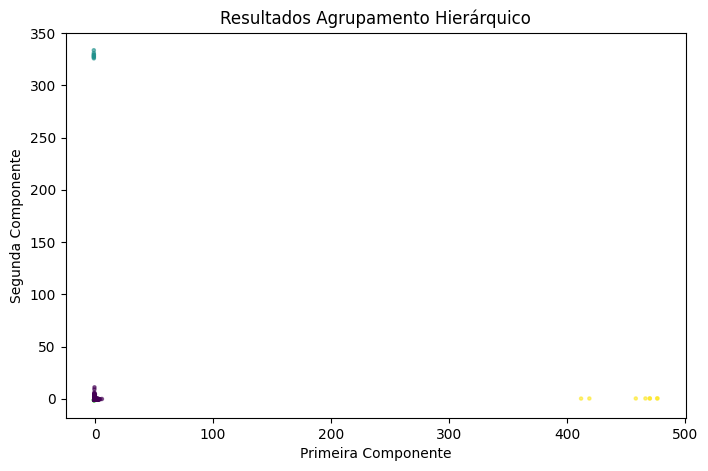

In [ ]:
matrixAH5 = doAgglomerativeClustering(5, pcaMatrix)

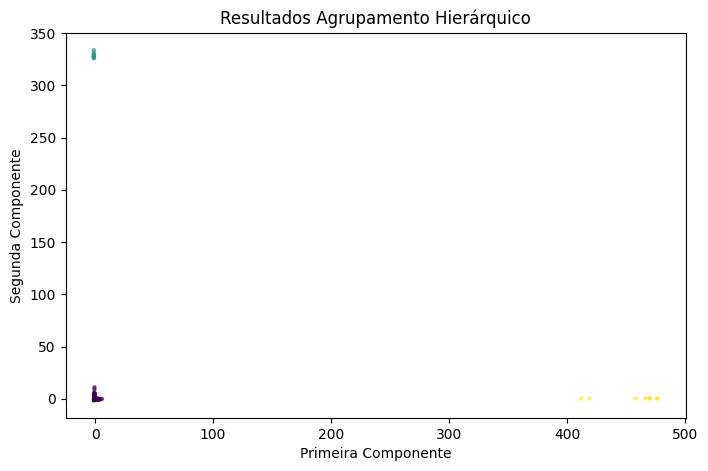

In [ ]:
matrixAH10 = doAgglomerativeClustering(10, pcaMatrix)

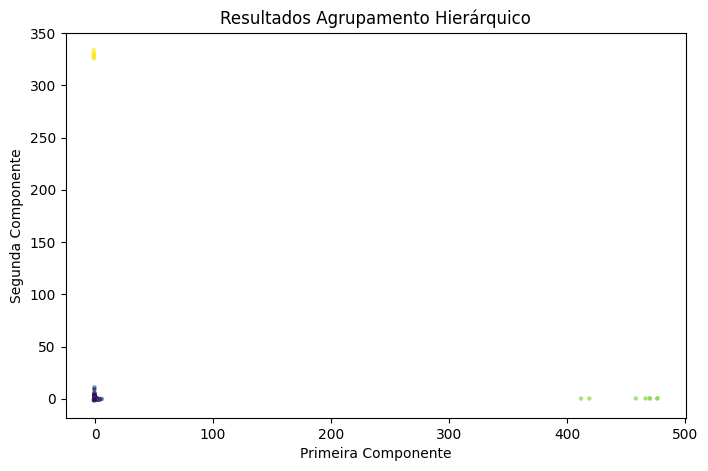

In [ ]:
matrixAH24 = doAgglomerativeClustering(24, pcaMatrix)

Devido à disposição das muitas componentes da matriz do PCA, o gráfico gerado aqui no agrupamento hierárquico para os 4 valores de diferentes clusters não fica muito visual. É difícil transmitir milhares de componentes em apenas duas em um gráfico. Mais a frente, analisaremos melhor esses resultados.

## Gêneros reais dos dados


A seguir, faremos uma análise com base na ocorrência de vezes em que os gêneros aparecem. Todos os que aparecem pouco serão descartados como gênero, a fim de não gerar um gráfico carregado de outliers, e também eliminaremos "gêneros" que se referem a coisas técnicas do lançamento do jogo e não do jogo em si.

A função abaixo exibe todos os gêneros que aparecem em uma determinada base de dados, informa em quantos jogos distintos eles estão presentes  e quantos combinações distintas de gêneros existem. A primeira célula possui a lista de todos os gêneros da base de dados original. A segunda utiliza o mesmo código para achar os gêneros da amostra aleatória recolhida.

In [ ]:
def agrupando(dataSet):
    dataSetGenres = dataSet['genres']
    pureGenres = []
    pureGenresAmount = [0] * 26
    multipleGenres = []
    multipleGenresAmount = [0] * 1500


    for i in dataSetGenres:
        if(multipleGenres.__contains__(i)==False):
            multipleGenres.append(i)
        index = multipleGenres.index(i)
        multipleGenresAmount[index] = multipleGenresAmount[index] +1
        individualGenres= i.split(';')

        for j in individualGenres:
           if(pureGenres.__contains__(j) == False):
               pureGenres.append(j)
           index2 = pureGenres.index(j)
           pureGenresAmount[index2] = pureGenresAmount[index2] +  1

    print('Combinações de gêneros diferentes: ', len(multipleGenres))
    for i in pureGenres:
        print(i, '  -  ', pureGenresAmount[pureGenres.index(i)], 'ocorrências'  )

    return pureGenres

In [ ]:
originalGenres = agrupando(steamFile)

Combinações de gêneros diferentes:  1260
Action   -   11903 ocorrências
Free to Play   -   1704 ocorrências
Strategy   -   5247 ocorrências
Adventure   -   10032 ocorrências
Indie   -   19421 ocorrências
RPG   -   4311 ocorrências
Animation & Modeling   -   79 ocorrências
Video Production   -   38 ocorrências
Casual   -   10210 ocorrências
Simulation   -   5194 ocorrências
Racing   -   1024 ocorrências
Violent   -   843 ocorrências
Massively Multiplayer   -   723 ocorrências
Sports   -   1322 ocorrências
Early Access   -   2954 ocorrências
Utilities   -   146 ocorrências
Design & Illustration   -   87 ocorrências
Web Publishing   -   28 ocorrências
Education   -   51 ocorrências
Software Training   -   31 ocorrências
Audio Production   -   29 ocorrências
Game Development   -   17 ocorrências
Photo Editing   -   12 ocorrências
Accounting   -   6 ocorrências
Documentary   -   1 ocorrências
Tutorial   -   1 ocorrências


In [ ]:
sampleGenres = agrupando(steamFileSample)

Combinações de gêneros diferentes:  713
Adventure   -   2991 ocorrências
Casual   -   2987 ocorrências
Indie   -   5721 ocorrências
Action   -   3509 ocorrências
RPG   -   1302 ocorrências
Strategy   -   1553 ocorrências
Simulation   -   1531 ocorrências
Sports   -   367 ocorrências
Free to Play   -   508 ocorrências
Massively Multiplayer   -   205 ocorrências
Early Access   -   841 ocorrências
Racing   -   296 ocorrências
Violent   -   242 ocorrências
Design & Illustration   -   23 ocorrências
Utilities   -   35 ocorrências
Web Publishing   -   8 ocorrências
Video Production   -   8 ocorrências
Animation & Modeling   -   18 ocorrências
Game Development   -   6 ocorrências
Audio Production   -   8 ocorrências
Photo Editing   -   2 ocorrências
Education   -   16 ocorrências
Software Training   -   10 ocorrências
Accounting   -   2 ocorrências


A seguir, devido a quantidade relativamente alta de 713 combinações de gêneros distintas, que aparecem uma ou mais vezes no dataset, decidimos gerar um mapa de calor para conseguir entender quais gêneros se relacionam fortemente entre si e podem acabar num mesmo agrupamento pelo algoritmo, dado que eles não foram feitos para lidar com múltiplas labels.

Ademais, antes de fazer o mapa removemos da análise alguns gêneros que não consideramos relevantes por se referirem a coisas técnicas do lançamento do jogo e não do jogo em si, então não os consideramos gêneros reais. Além destes, removemos gêneros que aparecem muito pouco com número abaixo do nosso min_df. São os gêneros removidos: Accounting, Documentary, Early Access, Free to Play, Massively Multiplayer, Tutorial, Video Production, Web Publishing, Audio Production, Photo Editing, Game Development e Software Training.

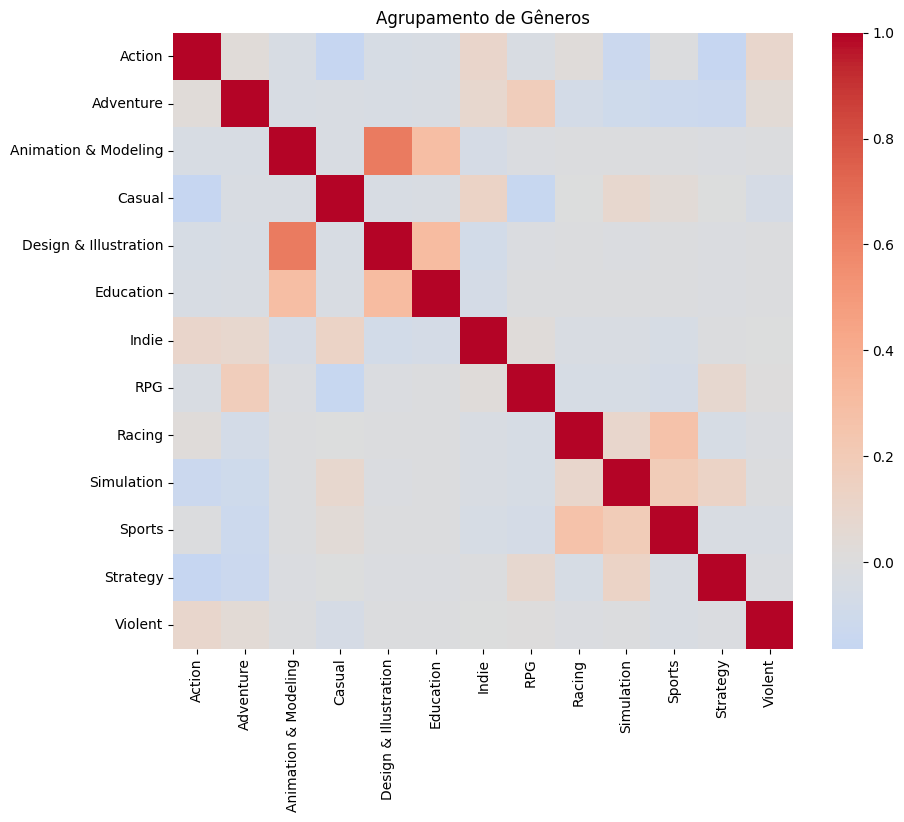

In [ ]:
def heatMapGenres(genreColumns):
    columnsList = []
    for genres in genreColumns:
        singleGenres = genres.split(';')
        if('Accounting' in singleGenres):
            singleGenres.remove('Accounting')
        if('Documentary' in singleGenres):
            singleGenres.remove('Documentary')
        if('Early Access' in singleGenres):
            singleGenres.remove('Early Access')
        if('Free to Play' in singleGenres):
            singleGenres.remove('Free to Play')
        if('Massively Multiplayer' in singleGenres):
            singleGenres.remove('Massively Multiplayer')
        if('Tutorial' in singleGenres):
            singleGenres.remove('Tutorial')
        if('Video Production' in singleGenres):
            singleGenres.remove('Video Production')
        if('Utilities' in singleGenres):
            singleGenres.remove('Utilities')
        if('Web Publishing' in singleGenres):
            singleGenres.remove('Web Publishing')
        if('Audio Production' in singleGenres):
            singleGenres.remove('Audio Production')
        if('Photo Editing' in singleGenres):
            singleGenres.remove('Photo Editing')
        if('Game Development' in singleGenres):
            singleGenres.remove('Game Development')
        if('Software Training' in singleGenres):
            singleGenres.remove('Software Training')
        columnsList.append(singleGenres)

    mlb = MultiLabelBinarizer()
    binaryGenres = mlb.fit_transform(columnsList)
    genres = pd.DataFrame(binaryGenres, columns=mlb.classes_)

    correlation = genres.corr()


    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation, annot=False, cmap='coolwarm', center=0)
    plt.title("Agrupamento de Gêneros")
    plt.show()

    return binaryGenres

binaryGenres = heatMapGenres(steamFileSample['genres'])

Dado o mapa de calor acima, podemos afirmar que existem gêneros que possuem forte correlação um com outro e, possivelmente, não estão sozinhos na coluna de gênero, mas sim unidos. As correlações de maior destaque são:



*   Animation & Modeling, Design & Illustration
*   Education, Design & Illustration
* Education,  Animation & Modeling
* Racing, Sports

E também temos gêneros que possuem correlações fracas, ou aparecem juntos poucas vezes ou não aparecem, como:


*   Strategy, Action
*   Casual, Action
*   Sports, Adventure
*  RPG, Casual
* Simulation, Action

Podemos concluir que, num processo de agrupamentos, esses gêneros deveriam seguir esse comportamento de:
- os com gêneros mais correlatos num mesmo cluster ou em clusters próximos; e
- os menos correlatos em clusters diferentes.

Deve-se observar também a quantidade de vezes que cada gênero aparece, pois é um fator limitante, já que um gênero que aparece muitas vezes poderia estar em um cluster com outro gênero que ele tem baixa correlação, se k for grande o suficiente, ou se outros gêneros com quem estiver associado possuirem associação significativa com o de baixa relação dele.





## Análise

Com o objetivo de analisar a efetividade dos algoritmos de agrupamento utilizados, criamos a função de pureza abaixo, com base no material desse [link](https://medium.com/@vincydesy96/evaluation-of-supervised-clustering-purity-from-scratch-3ce42e1491b1).

A função recebe os clusters criados pelo agrupamento a ser analisado e as classes originais dos jogos da amostra analisada. Para cada um dos clusters, as labels reais dos jogos que fazem parte desse cluster são armazenadas. Sabemos que alguns jogos têm mais de um gênero, no formato "g1;g2;g3". Assim, separamos esses gêneros com split e colocamos todos em uma lista de gêneros. Conseguimos, portanto, descobrir qual gênero é o mais comum de cada cluster e contabilizar a taxa de acerto do agrupamento. Além disso, também exibimos a distribuição de gêneros interna, de cada cluster.

A função de pureza descrita acima pode ser visualizada a seguir:

In [ ]:
def purity1(clust, ogClass):
  len_clust = len(clust)
  cluster_groups = {}

  #para cada cluster, guarda suas labels originais
  for i in range(len_clust):
    index = clust[i]
    true_label = ogClass[i]

    if index not in cluster_groups:
      cluster_groups[index] = []
    cluster_groups[index].append(true_label)

  purity = 0
  for c in cluster_groups:
    items = cluster_groups[c]

    #para cada cluster, armazena todos os generos reais de todos os jogos
    genres = []
    for item in items:
      genres.extend(item.split(';'))

    #contabiliza a ocorrencia de cada genero e pega o mais comum
    countGenres = Counter(genres)
    maxGenre = countGenres.most_common(1)[0][0]
    print(f"Cluster {c}: {countGenres}")

    #contabiliza o numero de jogos que possui o genero mais comum
    purity += genres.count(maxGenre)

  return purity/len_clust

### K-Means

In [ ]:
pureza = purity1(matrixKMeans9, steamFileSample['genres'].values)
print(f"Pureza do KMeans de k=9: {pureza}")

Cluster 6: Counter({'Indie': 5679, 'Action': 3500, 'Adventure': 2940, 'Casual': 2912, 'Strategy': 1538, 'Simulation': 1519, 'RPG': 1299, 'Early Access': 838, 'Free to Play': 508, 'Sports': 363, 'Racing': 293, 'Violent': 241, 'Massively Multiplayer': 205, 'Utilities': 35, 'Design & Illustration': 23, 'Animation & Modeling': 18, 'Education': 16, 'Software Training': 10, 'Web Publishing': 8, 'Video Production': 8, 'Audio Production': 8, 'Game Development': 6, 'Photo Editing': 2, 'Accounting': 2})
Cluster 2: Counter({'Casual': 9, 'Indie': 9, 'Action': 7, 'Simulation': 5, 'Adventure': 4, 'Early Access': 1, 'Violent': 1, 'Racing': 1, 'Sports': 1})
Cluster 7: Counter({'Casual': 41, 'Adventure': 40, 'Simulation': 1, 'Strategy': 1, 'Indie': 1})
Cluster 5: Counter({'Casual': 8, 'Indie': 8, 'Strategy': 8})
Cluster 8: Counter({'Indie': 22, 'Casual': 16, 'Adventure': 6, 'Strategy': 5, 'RPG': 3, 'Simulation': 3, 'Action': 2, 'Early Access': 1})
Cluster 1: Counter({'Indie': 1, 'Strategy': 1})
Cluster

In [ ]:
pureza = purity1(matrixKMeans15, steamFileSample['genres'].values)
print(f"Pureza do KMeans de k=15: {pureza}")

Cluster 3: Counter({'Indie': 5656, 'Action': 3497, 'Casual': 2926, 'Adventure': 2911, 'Strategy': 1534, 'Simulation': 1521, 'RPG': 1255, 'Early Access': 841, 'Free to Play': 508, 'Sports': 363, 'Racing': 296, 'Violent': 240, 'Massively Multiplayer': 205, 'Utilities': 35, 'Design & Illustration': 23, 'Animation & Modeling': 18, 'Education': 16, 'Software Training': 10, 'Web Publishing': 8, 'Video Production': 8, 'Audio Production': 8, 'Game Development': 6, 'Photo Editing': 2, 'Accounting': 2})
Cluster 1: Counter({'Casual': 41, 'Adventure': 40, 'Simulation': 1, 'Strategy': 1, 'Indie': 1})
Cluster 13: Counter({'Indie': 44, 'RPG': 44, 'Adventure': 33})
Cluster 11: Counter({'Casual': 8, 'Indie': 8, 'Strategy': 8})
Cluster 4: Counter({'Sports': 4, 'Simulation': 3, 'Indie': 1, 'Strategy': 1})
Cluster 12: Counter({'Casual': 3, 'Violent': 2, 'Action': 2, 'Adventure': 1, 'Indie': 1})
Cluster 10: Counter({'Casual': 8, 'Simulation': 6, 'Strategy': 6, 'Action': 5, 'Indie': 4})
Cluster 7: Counter({

In [ ]:
pureza = purity1(matrixKMeans24, steamFileSample['genres'].values)
print(f"Pureza do KMeans de k=24: {pureza}")

Cluster 21: Counter({'Indie': 3941, 'Adventure': 2421, 'Casual': 2297, 'Action': 1974, 'Simulation': 920, 'RPG': 838, 'Strategy': 732, 'Early Access': 422, 'Free to Play': 286, 'Sports': 161, 'Violent': 154, 'Racing': 119, 'Massively Multiplayer': 63, 'Utilities': 26, 'Design & Illustration': 13, 'Education': 11, 'Animation & Modeling': 9, 'Audio Production': 8, 'Web Publishing': 6, 'Video Production': 6, 'Software Training': 6, 'Accounting': 2, 'Game Development': 2, 'Photo Editing': 1})
Cluster 6: Counter({'Action': 1166, 'Indie': 1129, 'Casual': 415, 'Adventure': 333, 'Strategy': 291, 'RPG': 285, 'Early Access': 254, 'Free to Play': 148, 'Simulation': 101, 'Massively Multiplayer': 89, 'Sports': 80, 'Violent': 69, 'Racing': 55})
Cluster 9: Counter({'Simulation': 323, 'Indie': 245, 'Strategy': 144, 'Sports': 118, 'Racing': 116, 'Casual': 114, 'Early Access': 94, 'Action': 92, 'Adventure': 48, 'RPG': 40, 'Free to Play': 27, 'Massively Multiplayer': 22, 'Design & Illustration': 10, 'Ani

### Agrupamento Hierárquico

In [ ]:
pureza = purity1(matrixAH7, steamFileSample['genres'].values)
print(f"Pureza do Agrupamento Hierárquico de 7 clusters: {pureza}")

Cluster 0: Counter({'Indie': 5653, 'Action': 3497, 'Casual': 2921, 'Adventure': 2912, 'Strategy': 1538, 'Simulation': 1519, 'RPG': 1256, 'Early Access': 840, 'Free to Play': 508, 'Sports': 366, 'Racing': 295, 'Violent': 241, 'Massively Multiplayer': 205, 'Utilities': 35, 'Design & Illustration': 23, 'Animation & Modeling': 18, 'Education': 16, 'Software Training': 10, 'Web Publishing': 8, 'Video Production': 8, 'Audio Production': 8, 'Game Development': 6, 'Photo Editing': 2, 'Accounting': 2})
Cluster 2: Counter({'Indie': 46, 'RPG': 46, 'Adventure': 35})
Cluster 3: Counter({'Casual': 9, 'Indie': 9, 'Action': 7, 'Simulation': 5, 'Adventure': 4, 'Early Access': 1, 'Violent': 1, 'Racing': 1, 'Sports': 1})
Cluster 6: Counter({'Casual': 26, 'Adventure': 25, 'Simulation': 1, 'Strategy': 1})
Cluster 1: Counter({'Adventure': 15, 'Casual': 15, 'Indie': 1})
Cluster 4: Counter({'Casual': 8, 'Indie': 8, 'Strategy': 8})
Cluster 5: Counter({'Casual': 8, 'Simulation': 6, 'Strategy': 6, 'Action': 5, '

In [ ]:
pureza = purity1(matrixAH5, steamFileSample['genres'].values)
print(f"Pureza do Agrupamento Hierárquico de 5 clusters: {pureza}")

Cluster 0: Counter({'Indie': 5699, 'Action': 3497, 'Adventure': 2972, 'Casual': 2947, 'Strategy': 1539, 'Simulation': 1520, 'RPG': 1302, 'Early Access': 840, 'Free to Play': 508, 'Sports': 366, 'Racing': 295, 'Violent': 241, 'Massively Multiplayer': 205, 'Utilities': 35, 'Design & Illustration': 23, 'Animation & Modeling': 18, 'Education': 16, 'Software Training': 10, 'Web Publishing': 8, 'Video Production': 8, 'Audio Production': 8, 'Game Development': 6, 'Photo Editing': 2, 'Accounting': 2})
Cluster 3: Counter({'Casual': 9, 'Indie': 9, 'Action': 7, 'Simulation': 5, 'Adventure': 4, 'Early Access': 1, 'Violent': 1, 'Racing': 1, 'Sports': 1})
Cluster 1: Counter({'Adventure': 15, 'Casual': 15, 'Indie': 1})
Cluster 4: Counter({'Casual': 8, 'Indie': 8, 'Strategy': 8})
Cluster 2: Counter({'Casual': 8, 'Simulation': 6, 'Strategy': 6, 'Action': 5, 'Indie': 4})
Pureza do Agrupamento Hierárquico de 5 clusters: 0.717375


In [ ]:
pureza = purity1(matrixAH10, steamFileSample['genres'].values)
print(f"Pureza do Agrupamento Hierárquico de 10 clusters: {pureza}")

Cluster 0: Counter({'Indie': 5650, 'Action': 3497, 'Adventure': 2907, 'Casual': 2907, 'Strategy': 1534, 'Simulation': 1519, 'RPG': 1256, 'Early Access': 840, 'Free to Play': 508, 'Sports': 366, 'Racing': 295, 'Violent': 241, 'Massively Multiplayer': 205, 'Utilities': 35, 'Design & Illustration': 23, 'Animation & Modeling': 18, 'Education': 16, 'Software Training': 10, 'Web Publishing': 8, 'Video Production': 8, 'Audio Production': 8, 'Game Development': 6, 'Photo Editing': 2, 'Accounting': 2})
Cluster 2: Counter({'Indie': 38, 'RPG': 38, 'Adventure': 28})
Cluster 7: Counter({'Casual': 9, 'Indie': 9, 'Action': 7, 'Simulation': 5, 'Adventure': 4, 'Early Access': 1, 'Violent': 1, 'Racing': 1, 'Sports': 1})
Cluster 6: Counter({'Casual': 26, 'Adventure': 25, 'Simulation': 1, 'Strategy': 1})
Cluster 3: Counter({'Adventure': 15, 'Casual': 15, 'Indie': 1})
Cluster 9: Counter({'Casual': 8, 'Indie': 8, 'Strategy': 8})
Cluster 4: Counter({'Casual': 6, 'Adventure': 5})
Cluster 8: Counter({'Indie': 

In [ ]:
pureza = purity1(matrixAH24, steamFileSample['genres'].values)
print(f"Pureza do Agrupamento Hierárquico de 24 clusters: {pureza}")

Cluster 0: Counter({'Indie': 3425, 'Casual': 1958, 'Adventure': 1862, 'Action': 1840, 'Simulation': 863, 'Strategy': 719, 'RPG': 605, 'Early Access': 396, 'Free to Play': 286, 'Sports': 197, 'Violent': 145, 'Racing': 130, 'Massively Multiplayer': 77, 'Utilities': 26, 'Design & Illustration': 15, 'Education': 12, 'Animation & Modeling': 9, 'Web Publishing': 7, 'Audio Production': 7, 'Software Training': 7, 'Video Production': 5, 'Photo Editing': 2, 'Game Development': 2, 'Accounting': 1})
Cluster 10: Counter({'Indie': 2044, 'Action': 1541, 'Adventure': 957, 'Casual': 841, 'Strategy': 714, 'RPG': 616, 'Simulation': 576, 'Early Access': 405, 'Free to Play': 205, 'Racing': 156, 'Sports': 154, 'Massively Multiplayer': 117, 'Violent': 90, 'Animation & Modeling': 9, 'Utilities': 8, 'Design & Illustration': 7, 'Game Development': 4, 'Education': 3, 'Software Training': 2, 'Video Production': 2, 'Web Publishing': 1, 'Accounting': 1, 'Audio Production': 1})
Cluster 21: Counter({'Casual': 5, 'Ind

### Análise Geral

Como foi analisado no tópico de gêneros reais dos dados, o gênero mais comum da nossa amostra foi "Indie   -   5721 ocorrências". Isso pode variar a depender da amostra aleatória que foi gerada no início do trabalho. O gênero Indie representa 71,5125% dos jogos, pois 5721/8000 = 0.715125. Com isso, concluímos que um algoritmo de agrupamento puramente aleatório poderia ser capaz de acertar o gênero de aproximadamente 71,5% dos jogos, pois Indie está presente nessa porcentagem de amostras.

A partir disso, a conclusão é que qualquer algoritmo que faça uma pureza acima de 71,5% está fazendo um trabalho melhor do que apenas dividir em grupos menores e classificá-los como o gênero mais comum da amostra total, que é "Indie", nesse caso.

Os resultados obtidos ao executar a função de pureza, mostram que ambos os algoritmos possuem índices de pureza semelhantes entre si e próximos a 72%. Apenas uma das execuções que foi diferente desse padrão: k-means com k=24, que teve 75% de pureza. No agrupamento hierárquico, o maior valor de pureza foi com 24 clusters distintos, que obteve 72,58%. Considerando que 75% e 72% são porcentagens altas de acerto, de forma isolada, e que os métodos utilizados têm um cálculo e lógica por trás, não usando aleatoriedade, foi um resultado ok, mas não é nada surpreendentemente bom, pois um algoritmo puramente aleatório geraria resultados próximos disso. Logo, eles não fazem papéis incrivelmente eficientes no agrupamento das amostras. Eles apenas fazem o básico, levemente melhor do que o algoritmo aleatório.

Outrossim, quando olhamos os pares de correlações citados no mapa de calor acima, vemos que as componentes com forte correlação estão quase sempre juntas em um e, às vezes, mais clusters, dependendo do k - como Education, Animation & Modeling, Design & Illustration - e as de correlação mais 'frias' possuem um pouco mais de dificuldade para serem separadas, devido aos grandes volumes de alguns gêneros ou k grande, mas ainda assim apresentam ocorrências de clusters em que um aparece e outro não.

Poderíamos nos questionar se os dois algoritmos realmente estão analisando a matriz gerada no PCA para concluir os clusters, uma vez que os resultados foram bons, mas próximos da porcentagem de amostras que possui o gênero mais frequente. Porém, a função de pureza também exibiu a distribuição interna de gêneros de cada cluster em ordem decrescente e podemos observar que os clusters estão distribuidos de formas distintas internamente. Logo, os resultados realmente foram gerados a partir das descrições dos jogos que foram reduzidas a uma matriz no PCA, e geraram um resultado eficiente, o que mostra que as descrições possuem relação com os gêneros as quais representam.

Com isso, podemos concluir que os algoritmos fazem o seu papel, ainda que não sejam as opções de agrupamento totalmente efetivas, e analisam as descrições, que conseguem garantir entre 72 e 75% de exatidão de gêneros nos jogos agrupados, uma vez que as descrições possuem e descrevem relação com os gêneros dos seus respectivos jogos. Os resultados e conclusões finais são positivos, mas poderiam ser melhores.

## Referências


*   [Escolha do número de componentes do PCA ](https://medium.com/@riya190304/finding-optimal-number-of-components-in-pca-2141d2891bed)
*   [Silhueta e silhouette_score](https://hub.asimov.academy/blog/elbow-method-e-silhouette-score-numero-cluster/)
*   [Dendograma e gráfico de distâncias do agrupamento hierárquico](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html)
*   [MultiLabelBinarizer](https://medium.com/@mloyfer/exploring-sklearn-multilabel-binarizer-a000dec9784)
*   [Função de pureza](https://medium.com/@vincydesy96/evaluation-of-supervised-clustering-purity-from-scratch-3ce42e1491b1)
